In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo para gráficos mais profissionais
sns.set_theme(style="whitegrid")

# 1. Carregar o dataset gerado pelo download_data.py
try:
    try:
        df = pd.read_csv('../data/dataset.csv', sep=';')
    except pd.errors.ParserError:
        # fallback caso o ficheiro esteja separado por vírgula ou tenha linhas problemáticas
        df = pd.read_csv('../data/dataset.csv', sep=',', engine='python', on_bad_lines='skip')
    print(f"✅ Dataset carregado com sucesso! Total de textos: {len(df)}")
    # Normalizar nomes das colunas para evitar KeyError (ex.: 'Label' vs 'label')
    df.columns = df.columns.str.strip().str.lower()

    required_cols = {'id', 'text', 'label'}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise KeyError(f"Colunas em falta: {missing_cols}. Colunas disponíveis: {list(df.columns)}")

    print(f"✅ Classes presentes: {df['label'].unique()}")
except FileNotFoundError:
    print("❌ ERRO: Ficheiro '../data/dataset.csv' não encontrado. Corre o download.py primeiro!")

# Mostrar as primeiras 5 linhas
df.head()

✅ Dataset carregado com sucesso! Total de textos: 2465
✅ Classes presentes: ['OpenAI' 'Human' 'Anthropic' 'Meta' 'Google']


,id,text,label
0,D1-1,This research paper focuses on the use of atom...,OpenAI
1,D1-2,This research paper explores the integration o...,OpenAI
2,D1-3,This paper explores the period map for cubic f...,OpenAI
3,D1-4,A hybrid ferromagnet/semiconductor device is...,Human
4,D1-5,Neutrinoless double beta decay represents a ra...,Anthropic


C:\Users\Luimp\AppData\Local\Temp\ipykernel_1320\1914461292.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette='viridis',


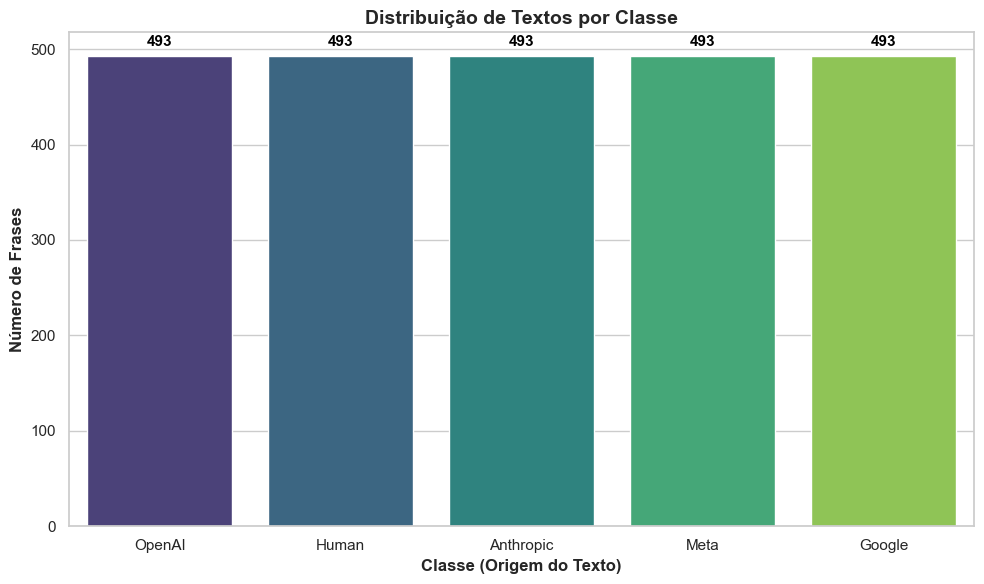

In [4]:
plt.figure(figsize=(10, 6))

# Criar o gráfico de barras com as contagens
ax = sns.countplot(data=df, x='label', palette='viridis', 
                   order=df['label'].value_counts().index)

plt.title('Distribuição de Textos por Classe', fontsize=14, fontweight='bold')
plt.xlabel('Classe (Origem do Texto)', fontsize=12, fontweight='bold')
plt.ylabel('Número de Frases', fontsize=12, fontweight='bold')

# Adicionar o número exato no topo de cada barra para facilitar a leitura
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', 
                color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

📏 Mínimo de palavras detetado globalmente: 76
📏 Máximo de palavras detetado globalmente: 120


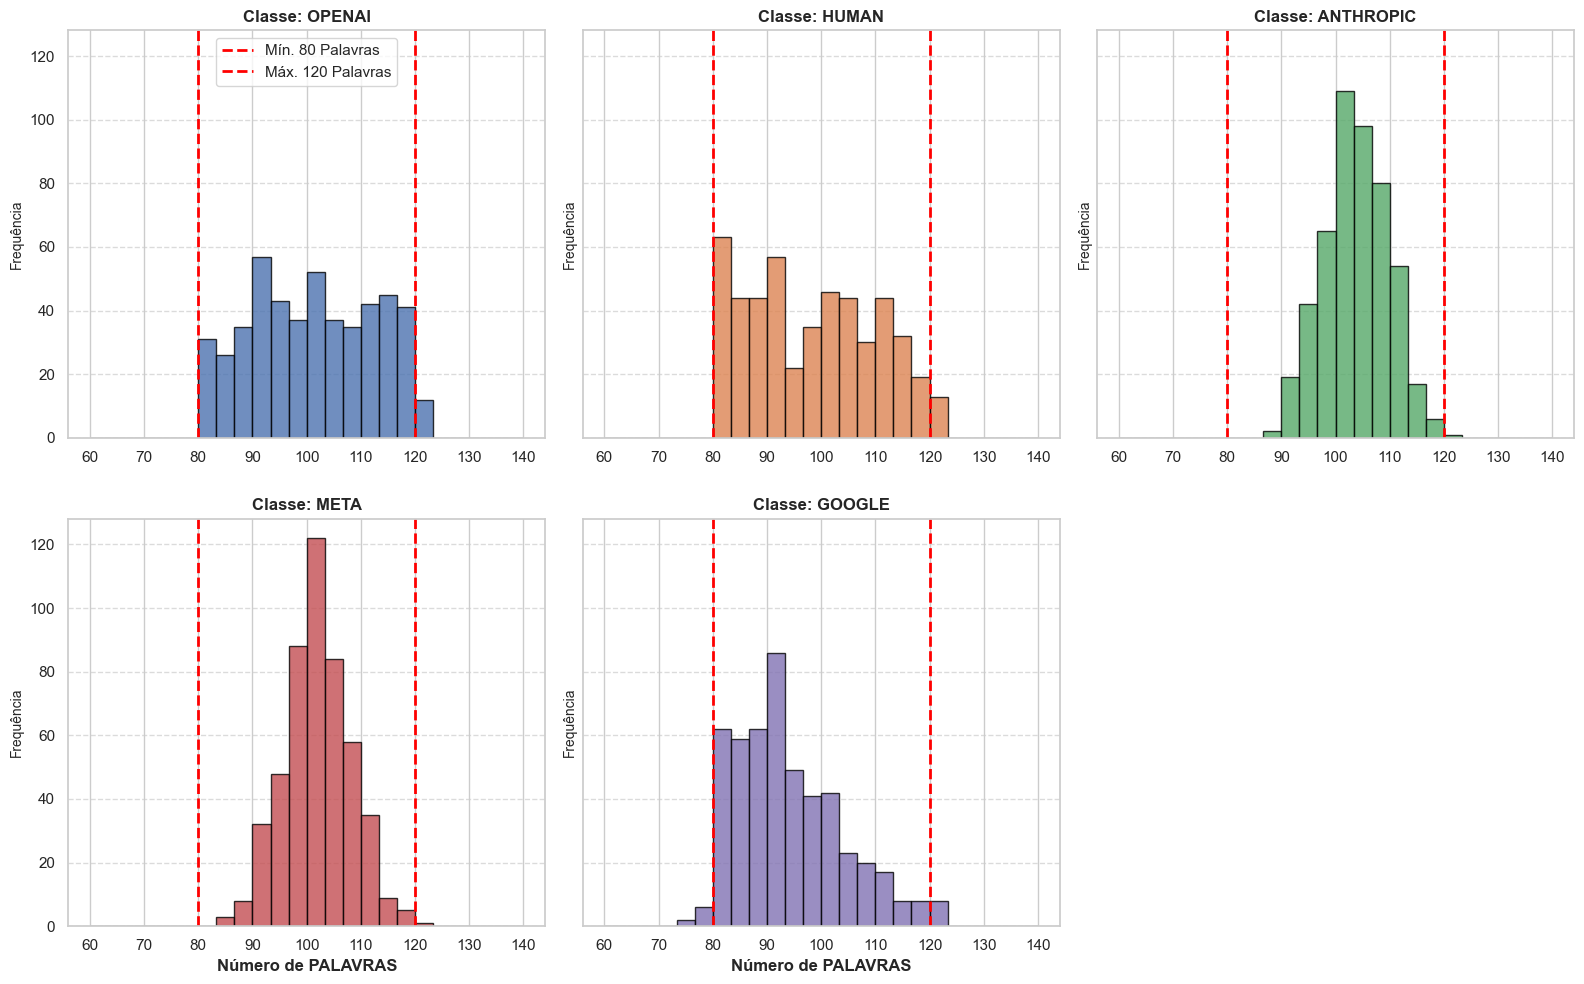

In [5]:
# 1. Contar PALAVRAS (em vez de caracteres) separando pelos espaços em branco
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print(f"📏 Mínimo de palavras detetado globalmente: {df['word_count'].min()}")
print(f"📏 Máximo de palavras detetado globalmente: {df['word_count'].max()}")

# 2. Configurar a grelha de gráficos (2 linhas x 3 colunas = 6 espaços)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()
cores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

# Definir os blocos do histograma para focar na zona de interesse
bins_globais = np.linspace(60, 140, 25) 

for i, classe in enumerate(df['label'].unique()):
    ax = axes[i]
    dados_classe = df[df['label'] == classe]['word_count']
    
    # Desenhar o histograma para a classe atual
    ax.hist(dados_classe, bins=bins_globais, alpha=0.8, 
            color=cores[i % len(cores)], edgecolor='black')
    
    # 3. As linhas vermelhas delimitadoras do Professor
    ax.axvline(x=80, color='red', linestyle='dashed', linewidth=2, label='Mín. 80 Palavras')
    ax.axvline(x=120, color='red', linestyle='dashed', linewidth=2, label='Máx. 120 Palavras')
    
    ax.set_title(f'Classe: {classe.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequência', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Forçar a exibição do eixo X em todos os gráficos
    ax.tick_params(labelbottom=True)
    
    if i == 0:
        ax.legend()

# Como só temos 5 classes, apagamos o 6º gráfico (vazio)
fig.delaxes(axes[5])

# Colocar a legenda do eixo X nos gráficos da linha de baixo
for ax in axes[-3:]:
    ax.set_xlabel('Número de PALAVRAS', fontsize=12, fontweight='bold')

plt.tight_layout(h_pad=2.0)
plt.show()